# Optimizing lattice constants for hcp Ni

This notebook compares two ways to optimize the two independent lattice constants of hexagonal close-packed (hcp) Ni with ASE and EMT. The first fits a quadratic energy surface $E(a,c)$ to a small grid of cells; the second changes the cell directly until the EMT stress approaches zero.

Using hcp makes this a useful two-parameter optimization exercise. The numerical results are specific to the hcp structure and EMT model used here; the notebook does not compare crystal phases or establish the stable phase of Ni.

## Initial lattice parameters

The initial basal-plane parameter is set to $a_0 = 3.52/\sqrt{2}$ Å. The code does not record the provenance of the 3.52 Å reference value, so it is best treated here as a starting length scale rather than a validated result. The initial axial parameter uses the ideal close-packed ratio

$$
\frac{c_0}{a_0} = \sqrt{\frac{8}{3}}.
$$

`bulk('Ni', 'hcp', ...)` later creates a two-atom periodic cell, while EMT supplies the total potential energy and stress.

In [1]:
import numpy as np

from ase.build import bulk
from ase.calculators.emt import EMT
from ase.filters import StrainFilter  # Import for stress tensor calculation
from ase.io import Trajectory, read
from ase.optimize import BFGS  # Import for stress tensor calculation

a0 = 3.52 / np.sqrt(2)
c0 = np.sqrt(8 / 3.0) * a0

## Sampling a two-dimensional energy surface

The trajectory is opened in write mode to collect the sampled structures and their EMT energies. Running this cell again replaces the existing `Ni.traj`.

In [2]:
traj = Trajectory('../files/advanced/tutorial_03/Ni.traj', 'w')

### Building the $3 \times 3$ scan

Both $a$ and $c$ are varied independently by $\pm 1\%$ around their starting values. Three values along each direction produce nine hcp cells. For every cell, the potential energy is evaluated before writing so the calculated EMT result is stored in the trajectory. This grid is sufficient to determine a six-parameter quadratic model, but it leaves only three additional data points with which to assess the fit.

In [3]:
eps = 0.01
for a in a0 * np.linspace(1 - eps, 1 + eps, 3):
    for c in c0 * np.linspace(1 - eps, 1 + eps, 3):
        ni = bulk('Ni', 'hcp', a=a, c=c)
        ni.calc = EMT()
        ni.get_potential_energy()
        traj.write(ni)

## Fitting the energy surface

ASE represents the hcp cell with three lattice vectors. For the orientation produced here, `cell[0, 0]` equals the basal lattice constant $a$ and `cell[2, 2]` equals the axial lattice constant $c$. The printed example makes that convention explicit before those entries are extracted from the trajectory.

In [4]:
ni = bulk('Ni', 'hcp', a=2.5, c=4.0)
print(ni.cell)

Cell([[2.5, 0.0, 0.0], [-1.25, 2.1650635094610964, 0.0], [0.0, 0.0, 4.0]])


### Reading the sampled data

The `@:` selector reads every frame from `Ni.traj`. `energies` contains total potential energies in eV for the two-atom cells, while the arrays `a` and `c` contain lattice constants in Å. The extraction relies on the cell orientation demonstrated above and is not a general recipe for arbitrary cell matrices.

In [5]:
configs = read('../files/advanced/tutorial_03/Ni.traj@:')
energies = [config.get_potential_energy() for config in configs]
a = np.array([config.cell[0, 0] for config in configs])
c = np.array([config.cell[2, 2] for config in configs])

### Least-squares quadratic model

The fitted surface has the form

$$
E(a,c) = p_0 + p_1a + p_2c + p_3a^2 + p_4ac + p_5c^2.
$$

Each row of `functions.T` evaluates these six basis terms for one sampled cell. `np.linalg.lstsq` then finds the coefficients that minimize the summed squared energy residuals over all nine samples.

In [6]:
functions = np.array([a**0, a, c, a**2, a * c, c**2])
p = np.linalg.lstsq(functions.T, energies, rcond=-1)[0]

### Locating the stationary point

At a stationary point, the two first derivatives vanish:

$$
\nabla E = (p_1 + 2p_3a + p_4c,\; p_2 + p_4a + 2p_5c) = 0.
$$

The matrix `p2` is the Hessian of the quadratic surface,

$$
H = \begin{bmatrix}2p_3 & p_4 \\ p_4 & 2p_5\end{bmatrix},
$$

and solving $H(a,c)^T = -(p_1,p_2)^T$ gives the fitted stationary lattice constants. A stationary point is a minimum only when the Hessian is positive definite; the current code does not check that condition explicitly. The fitted values are saved without a header as `lattice_constant.csv` and printed in Å.

In [7]:
p0 = p[0]
p1 = p[1:3]
p2 = np.array([(2 * p[3], p[4]), (p[4], 2 * p[5])])
a0, c0 = np.linalg.solve(p2.T, -p1)

# Save the lattice constants to a file
with open('../files/advanced/tutorial_03/lattice_constant.csv', 'w') as fd:
    fd.write(f'{a0:.3f}, {c0:.3f}\n')

# Show the results on screen:
print('The optimized lattice constants are:')
print(f'a = {a0:.3f} Å, c = {c0:.3f} Å')

The optimized lattice constants are:
a = 2.466 Å, c = 4.023 Å


### Interpreting and visualizing the fit

The quadratic fit gives $a = 2.466$ Å and $c = 4.023$ Å, corresponding to $c/a \approx 1.631$. The axial result lies essentially on the lower edge of the original $\pm 1\%$ scan, so the minimum is not comfortably bracketed in both directions. A wider or denser scan would provide a stronger convergence check.

For visualization, the fitted polynomial is evaluated on a $100 \times 100$ grid centered on the fitted constants. Transposing `E` aligns $c$ with the horizontal axis and $a$ with the vertical axis in `imshow`. The colors represent the fitted total energy in eV for the two-atom cell; this is an interpolated surface rather than additional EMT calculations.

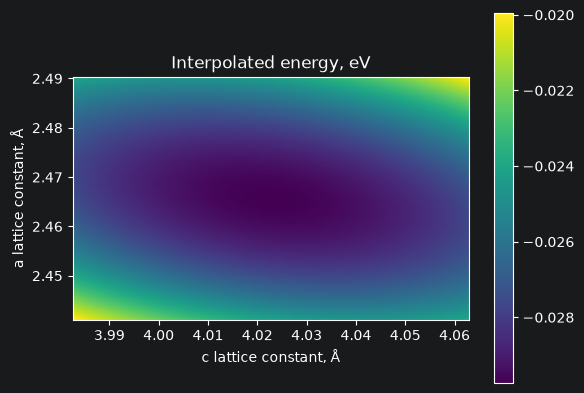

In [8]:
import matplotlib.pyplot as plt

a_int = a0 * np.linspace(1 - eps, 1 + eps, 100)
c_int = c0 * np.linspace(1 - eps, 1 + eps, 100)

a_int_grid, c_int_grid = np.meshgrid(a_int, c_int)

E = (
    p[0]
    + p[1] * a_int_grid
    + p[2] * c_int_grid
    + p[3] * a_int_grid**2
    + p[4] * a_int_grid * c_int_grid
    + p[5] * c_int_grid**2
)

plt.imshow(
    E.T,
    cmap='viridis',
    origin='lower',
    extent=[min(c_int), max(c_int), min(a_int), max(a_int)],
)
plt.colorbar()
plt.title('Interpolated energy, eV')
plt.xlabel('c lattice constant, Å')
plt.ylabel('a lattice constant, Å')
plt.show()

## Relaxing the cell from the stress tensor

The second route avoids fitting a predefined $(a,c)$ grid. It begins from a separate hcp Ni cell with $a = 3.0$ Å and $c = 5.0$ Å, attaches EMT, and varies the cell until its generalized stress forces converge. Because both routes use the same structure and calculator, this comparison tests numerical consistency between two optimization procedures rather than agreement with an independent physical reference.

In [9]:
ni = bulk('Ni', 'hcp', a=3.0, c=5.0)
ni.calc = EMT()

### StrainFilter and BFGS

`StrainFilter` presents the six homogeneous strain components as generalized coordinates while keeping the atoms' scaled positions fixed. Its generalized force is $-V\sigma$, where $V$ is the cell volume and $\sigma$ is the stress tensor. BFGS therefore changes the periodic cell rather than individual Cartesian atomic positions.

> **Convergence-unit note:** for `StrainFilter`, stress in eV/Å$^3$ is multiplied by volume in Å$^3$. The reported `fmax` and the `0.005` threshold therefore apply to generalized strain forces with energy units, not directly to a stress of $0.005$ eV/Å$^3$ as the inline code comment suggests.

With no mask supplied, all six strain components are available. For a symmetry-sensitive study, the final cell shape and stress components should also be inspected rather than assuming that only $a$ and $c$ changed.

In [10]:
sf = StrainFilter(ni)
opt = BFGS(sf)
opt.run(0.005)  # run until forces are below 0.005 eV/Å³

      Step     Time          Energy          fmax
BFGS:    0 19:22:02        2.697838       11.456177
BFGS:    1 19:22:02        0.885752        8.925609
BFGS:    2 19:22:02        0.094401        4.475456
BFGS:    3 19:22:02       -0.007973        1.687704
BFGS:    4 19:22:02       -0.029392        0.206563
BFGS:    5 19:22:02       -0.029737        0.023818
BFGS:    6 19:22:02       -0.029743        0.006381
BFGS:    7 19:22:02       -0.029743        0.000020


np.True_

### Inspecting convergence

The optimizer reduces the generalized `fmax` from about 11.46 to $2 \times 10^{-5}$ and returns `True`, indicating convergence under the requested threshold. `StrainFilter` updates the underlying `ni` object in place, so the following cell reads the relaxed lattice constants directly from its final cell matrix.

In [11]:
print('The optimized lattice constants from the stress tensor are:')
print(f'a = {ni.cell[0, 0]:.3f} Å, c = {ni.cell[2, 2]:.3f} Å')

The optimized lattice constants from the stress tensor are:
a = 2.466 Å, c = 4.025 Å


## Comparing the two estimates

The quadratic energy-surface fit gives $(a,c) = (2.466, 4.023)$ Å, while the stress relaxation gives $(2.466, 4.025)$ Å. The values of $a$ agree to the displayed precision, and the $c$ values differ by $0.002$ Å, approximately $0.05\%$. This close agreement supports the numerical implementation, but both estimates inherit the same EMT model assumptions.

## Takeaways and possible extensions

- A two-dimensional lattice optimization can be approached by fitting $E(a,c)$ or by relaxing the cell using stress-derived generalized forces.
- The quadratic fit is interpretable and inexpensive, but its stationary point must be checked for positive curvature and should be bracketed by the sampled grid.
- The highest-value extension is to widen and densify the $(a,c)$ scan, then report the fit residual or RMSE and the Hessian eigenvalues. This directly tests whether the apparent minimum is stable, especially because the fitted $c$ lies at the present scan boundary.
- The energy map would be more informative as a contour plot with the nine EMT samples, fitted minimum, and stress-relaxed result marked explicitly.
- Reporting $c/a$, the final stress tensor, and the percent difference between the two methods would turn their visual agreement into quantitative diagnostics.
- For reproducibility, `lattice_constant.csv` could include a header, units, calculator, structure, scan range, and fit model. A higher-fidelity calculator or reference dataset would be needed for a physical accuracy comparison.